In [2]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

#pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave/fes")
pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave/11")

rows = []

for npz_path in sorted(pred_dir.glob("*.npz")):
    fname = npz_path.name

    # keep ONLY IFT aggregator + IFT update runs
    if ("agg-ift" not in fname) or ("ift_update" not in fname):
        continue

    arr = np.load(npz_path)
    times = arr["times"]
    y_true = arr["y_true"]
    y_pred = arr["y_pred"]

    # flatten everything for global metrics
    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    mae = np.mean(np.abs(true_flat - pred_flat))
    rmse = np.sqrt(np.mean((true_flat - pred_flat) ** 2))

    # global Pearson / Spearman
    if np.std(true_flat) < 1e-12 or np.std(pred_flat) < 1e-12:
        global_pearson = np.nan
        global_spearman = np.nan
    else:
        global_pearson = pearsonr(true_flat, pred_flat)[0]
        global_spearman = spearmanr(true_flat, pred_flat)[0]

    # node-wise Pearson / Spearman
    T, N, D = y_true.shape
    node_pearsons = []
    node_spearmans = []

    for node_idx in range(N):
        for d in range(D):
            t_node = y_true[:, node_idx, d]
            p_node = y_pred[:, node_idx, d]

            if np.std(t_node) < 1e-12 or np.std(p_node) < 1e-12:
                continue

            node_pearsons.append(pearsonr(t_node, p_node)[0])
            node_spearmans.append(spearmanr(t_node, p_node)[0])

    mean_node_pearson = np.mean(node_pearsons) if node_pearsons else np.nan
    median_node_pearson = np.median(node_pearsons) if node_pearsons else np.nan
    mean_node_spearman = np.mean(node_spearmans) if node_spearmans else np.nan
    median_node_spearman = np.median(node_spearmans) if node_spearmans else np.nan

    # strip file extension
    run_name = npz_path.stem

    # remove seed from the config label so we can group across seeds
    # example: "...|seed=0" or "..._seed=0"
    model_config = re.sub(r'([|_])seed=\d+', '', run_name)

    # if your filenames have dataset prefix/suffix junk you want to remove,
    # you can tweak model_config here later

    seed_match = re.search(r'seed=(\d+)', run_name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    rows.append({
        "file": fname,
        "run_name": run_name,
        "model_config": model_config,
        "seed": seed,
        "mae": mae,
        "rmse": rmse,
        "global_pearson": global_pearson,
        "global_spearman": global_spearman,
        "mean_node_pearson": mean_node_pearson,
        "median_node_pearson": median_node_pearson,
        "mean_node_spearman": mean_node_spearman,
        "median_node_spearman": median_node_spearman,
    })

metrics_df = pd.DataFrame(rows)

print("Number of IFT + IFT update prediction files found:", len(metrics_df))
#display(metrics_df.head())

# group across seeds to get one row per exact model config (without seed)
config_metrics_df = (
    metrics_df
    .groupby("model_config", as_index=False)
    .agg(
        avg_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        avg_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        avg_global_pearson=("global_pearson", "mean"),
        std_global_pearson=("global_pearson", "std"),
        avg_global_spearman=("global_spearman", "mean"),
        std_global_spearman=("global_spearman", "std"),
        n_seeds=("file", "count"),
    )
)

#display(config_metrics_df.sort_values("avg_global_pearson", ascending=False).head(10))
#display(config_metrics_df.sort_values("avg_global_spearman", ascending=False).head(10))

Number of IFT + IFT update prediction files found: 180


In [3]:
true_flat = y_true.reshape(-1)
pred_flat = y_pred.reshape(-1)

print("true std :", np.std(true_flat))
print("pred std :", np.std(pred_flat))
print("pred/true std ratio :", np.std(pred_flat) / (np.std(true_flat) + 1e-12))

true std : 0.0021910341
pred std : 0.0015489248
pred/true std ratio : 0.7069378


In [4]:
a, b = np.polyfit(true_flat, pred_flat, 1)
print("slope a:", a)
print("intercept b:", b)

slope a: -0.0046844878464833385
intercept b: 0.0002125820446205855


In [5]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave/11")

rows = []

for npz_path in sorted(pred_dir.glob("*.npz")):
    fname = npz_path.name

    # keep ONLY IFT aggregator + IFT update runs
    if ("agg-ift" not in fname) or ("ift_update" not in fname):
        continue

    arr = np.load(npz_path)
    y_true = arr["y_true"]
    y_pred = arr["y_pred"]

    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    # finite mask just in case
    mask = np.isfinite(true_flat) & np.isfinite(pred_flat)
    true_flat = true_flat[mask]
    pred_flat = pred_flat[mask]

    if len(true_flat) == 0:
        continue

    mae = np.mean(np.abs(true_flat - pred_flat))
    rmse = np.sqrt(np.mean((true_flat - pred_flat) ** 2))

    std_true = np.std(true_flat)
    std_pred = np.std(pred_flat)
    std_ratio = std_pred / (std_true + 1e-12)

    if std_true < 1e-12 or std_pred < 1e-12:
        global_pearson = np.nan
        global_spearman = np.nan
        slope = np.nan
        intercept = np.nan
    else:
        global_pearson = pearsonr(true_flat, pred_flat)[0]
        global_spearman = spearmanr(true_flat, pred_flat)[0]

        # fit pred = slope * true + intercept
        slope, intercept = np.polyfit(true_flat, pred_flat, 1)

    run_name = npz_path.stem
    model_config = re.sub(r'([|_])seed=\d+', '', run_name)

    seed_match = re.search(r'seed=(\d+)', run_name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    rows.append({
        "file": fname,
        "run_name": run_name,
        "model_config": model_config,
        "seed": seed,
        "mae": mae,
        "rmse": rmse,
        "global_pearson": global_pearson,
        "global_spearman": global_spearman,
        "std_true": std_true,
        "std_pred": std_pred,
        "std_ratio": std_ratio,
        "slope": slope,
        "intercept": intercept,
    })

diagnostic_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

print("Top 10 runs by std_ratio")
display(
    diagnostic_df
    .sort_values("std_ratio", ascending=False)
    .head(10)[[
        "run_name", "std_ratio",
        "slope", "global_pearson", "global_spearman", "mae", "rmse"
    ]]
)

print("Top 10 runs by slope")
display(
    diagnostic_df
    .sort_values("slope", ascending=False)
    .head(10)[[
        "run_name", "std_ratio",
        "slope", "global_pearson", "global_spearman", "mae", "rmse"
    ]]
)

Top 10 runs by std_ratio


,run_name,std_ratio,slope,global_pearson,global_spearman,mae,rmse
85,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.1__k0-0.1__cap-none_seed-123,2.882222,0.016853,0.005847,0.011111,0.005141,0.007058
64,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-0.5__cap-none_seed-123,2.522298,0.013800,0.005471,0.007826,0.004161,0.006042
100,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-0.5__cap-none_seed-123,2.256295,0.012657,0.005609,-0.000605,0.003252,0.005451
140,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.1__k0-1.0__cap-none_seed-42,1.987112,-0.012033,-0.006056,0.005143,0.002977,0.005094
68,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-1.0__cap-none_seed-42,1.908250,0.018537,0.009714,0.012628,0.003495,0.004846
121,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.0__k0-0.1__cap-none_seed-123,1.885280,0.000685,0.000363,-0.009679,0.003128,0.004739
133,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.1__k0-0.1__cap-none_seed-123,1.803411,0.009193,0.005097,0.011689,0.002840,0.004550
76,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.5__cap-none_seed-123,1.762018,0.005352,0.003037,-0.006450,0.003503,0.004823
48,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.01__k0-0.1__cap-none_seed-0,1.761419,-0.010043,-0.005702,-0.023086,0.003849,0.005423
110,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.05__k0-0.1__cap-none_seed-42,1.735057,-0.002084,-0.001201,-0.010083,0.002782,0.004542


Top 10 runs by slope


,run_name,std_ratio,slope,global_pearson,global_spearman,mae,rmse
68,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-1.0__cap-none_seed-42,1.908250,0.018537,0.009714,0.012628,0.003495,0.004846
85,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.1__k0-0.1__cap-none_seed-123,2.882222,0.016853,0.005847,0.011111,0.005141,0.007058
64,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-0.5__cap-none_seed-123,2.522298,0.013800,0.005471,0.007826,0.004161,0.006042
75,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.5__cap-none_seed-0,1.089058,0.013752,0.012627,0.027183,0.002536,0.003245
100,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-0.5__cap-none_seed-123,2.256295,0.012657,0.005609,-0.000605,0.003252,0.005451
107,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-2.0__cap-none_seed-42,0.795622,0.012020,0.015108,0.008631,0.002436,0.003187
53,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.01__k0-0.5__cap-none_seed-42,1.480012,0.011383,0.007691,0.021845,0.002889,0.003945
103,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-1.0__cap-none_seed-123,1.334165,0.011076,0.008302,0.015468,0.002513,0.003731
74,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.1__cap-none_seed-42,1.516489,0.010371,0.006839,0.008233,0.003083,0.003969
89,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.1__k0-0.5__cap-none_seed-42,1.192555,0.010357,0.008685,0.004440,0.002719,0.003401


In [6]:
import re
import numpy as np
import pandas as pd

df = diagnostic_df.copy()   # or metrics_df.copy()

def parse_run_name(run_name: str) -> dict:
    """
    Parse names like:
    agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-1.0_seed-0
    """
    out = {
        "aggregator": np.nan,
        "update": np.nan,
        "dropout": np.nan,
        "pdo": np.nan,
        "time": np.nan,
        "kappa_param": np.nan,
        "dt": np.nan,
        "gamma": np.nan,
        "k0": np.nan,
        "cap": np.nan,
        "seed": np.nan,
    }

    s = str(run_name)

    # split off seed first
    seed_match = re.search(r'_seed-(\d+)$', s)
    if seed_match:
        out["seed"] = int(seed_match.group(1))
        s = re.sub(r'_seed-\d+$', '', s)

    parts = s.split("__")

    for part in parts:
        if part.startswith("agg-"):
            out["aggregator"] = part[len("agg-"):]
        elif part.startswith("update-"):
            out["update"] = part[len("update-"):]
        elif part.startswith("do-"):
            out["dropout"] = float(part[len("do-"):])
        elif part.startswith("pdo-"):
            out["pdo"] = float(part[len("pdo-"):])
        elif part.startswith("time-"):
            val = part[len("time-"):]
            out["time"] = True if val == "True" else False if val == "False" else val
        elif part in ("exp", "softplus"):
            out["kappa_param"] = part
        elif part.startswith("dt-"):
            out["dt"] = float(part[len("dt-"):])
        elif part.startswith("gamma-"):
            out["gamma"] = float(part[len("gamma-"):])
        elif part.startswith("k0-"):
            out["k0"] = float(part[len("k0-"):])
        elif part.startswith("cap-"):
            val = part[len("cap-"):]
            if val == "none":
                out["cap"] = "none"
            else:
                try:
                    out["cap"] = float(val)
                except ValueError:
                    out["cap"] = val

    return out

parsed = df["run_name"].apply(parse_run_name).apply(pd.Series)
analysis_df = pd.concat([df.reset_index(drop=True), parsed.reset_index(drop=True)], axis=1)

#display(analysis_df.head())

In [7]:
metric = "slope"   # change to global_spearman, std_ratio, slope, etc.

param_cols = [
    "aggregator", "update", "dropout", "pdo", "time",
    "kappa_param", "dt", "gamma", "k0", "cap"
]

summary_tables = {}

for col in param_cols:
    tbl = (
        analysis_df
        .groupby(col, dropna=False)
        .agg(
            mean_metric=(metric, "mean"),
            std_metric=(metric, "std"),
            n=(metric, "count"),
        )
        .reset_index()
        .sort_values("mean_metric", ascending=False)
    )
    summary_tables[col] = tbl
    print(f"\n=== {col} ===")
    display(tbl)

# rough "how much does this parameter seem to matter?"
importance_rows = []
for col, tbl in summary_tables.items():
    spread = tbl["mean_metric"].max() - tbl["mean_metric"].min()
    importance_rows.append({
        "parameter": col,
        "mean_metric_spread": spread,
        "num_levels": len(tbl),
    })

importance_df = pd.DataFrame(importance_rows).sort_values("mean_metric_spread", ascending=False)
print("\n=== Rough parameter influence ranking ===")
display(importance_df)


=== aggregator ===


,aggregator,mean_metric,std_metric,n
0,ift,-0.000019,0.005549,180



=== update ===


,update,mean_metric,std_metric,n
0,ift_update,-0.000019,0.005549,180



=== dropout ===


...

,k0,mean_metric,std_metric,n
1,0.5,0.001268,0.005602,48
2,1.0,0.000305,0.005757,48
3,2.0,0.000293,0.003552,36
0,0.1,-0.001863,0.006165,48



=== cap ===


,cap,mean_metric,std_metric,n
0,none,-0.000019,0.005549,180



=== Rough parameter influence ranking ===


,parameter,mean_metric_spread,num_levels
6,dt,0.003796,4
8,k0,0.003130,4
7,gamma,0.001614,4
0,aggregator,0.000000,1
1,update,0.000000,1
2,dropout,0.000000,1
5,kappa_param,0.000000,1
4,time,0.000000,1
3,pdo,0.000000,1
9,cap,0.000000,1


In [8]:
metric = "slope"
top_k = 20

top_df = (
    analysis_df
    .sort_values(metric, ascending=False)
    .head(top_k)
    .copy()
)

print("Top runs:")
display(top_df[[
    "run_name", metric, "aggregator", "update", "kappa_param",
    "dt", "gamma", "k0", "cap", "dropout", "pdo"
]])

# Frequency of each single parameter value in top-k
for col in ["aggregator", "update", "kappa_param", "dt", "gamma", "k0", "cap", "dropout", "pdo"]:
    print(f"\n=== Top {top_k} frequency: {col} ===")
    display(top_df[col].value_counts(dropna=False).reset_index().rename(
        columns={"index": col, col: "count"}
    ))

# Pairwise combinations that show up together
pair_cols = [
    ("dt", "gamma"),
    ("dt", "k0"),
    ("gamma", "k0"),
    ("kappa_param", "dt"),
    ("kappa_param", "gamma"),
    ("cap", "dt"),
    ("cap", "gamma"),
]

for c1, c2 in pair_cols:
    print(f"\n=== Top {top_k} combo frequency: ({c1}, {c2}) ===")
    display(
        top_df
        .groupby([c1, c2])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

Top runs:


,run_name,slope,aggregator,update,kappa_param,dt,gamma,k0,cap,dropout,pdo
68,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-1.0__cap-none_seed-42,0.018537,ift,ift_update,exp,0.05,0.05,1.0,none,0.0,0.0
85,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.1__k0-0.1__cap-none_seed-123,0.016853,ift,ift_update,exp,0.05,0.10,0.1,none,0.0,0.0
64,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-0.5__cap-none_seed-123,0.013800,ift,ift_update,exp,0.05,0.05,0.5,none,0.0,0.0
75,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.5__cap-none_seed-0,0.013752,ift,ift_update,exp,0.05,0.00,0.5,none,0.0,0.0
100,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-0.5__cap-none_seed-123,0.012657,ift,ift_update,exp,0.10,0.01,0.5,none,0.0,0.0
107,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-2.0__cap-none_seed-42,0.012020,ift,ift_update,exp,0.10,0.01,2.0,none,0.0,0.0
53,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.01__k0-0.5__cap-none_seed-42,0.011383,ift,ift_update,exp,0.05,0.01,0.5,none,0.0,0.0
103,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-1.0__cap-none_seed-123,0.011076,ift,ift_update,exp,0.10,0.01,1.0,none,0.0,0.0
74,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.1__cap-none_seed-42,0.010371,ift,ift_update,exp,0.05,0.00,0.1,none,0.0,0.0
89,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.1__k0-0.5__cap-none_seed-42,0.010357,ift,ift_update,exp,0.05,0.10,0.5,none,0.0,0.0



=== Top 20 frequency: aggregator ===


,count,count
0,ift,20



=== Top 20 frequency: update ===


...

,kappa_param,gamma,count
1,exp,0.01,8
3,exp,0.10,8
0,exp,0.00,2
2,exp,0.05,2



=== Top 20 combo frequency: (cap, dt) ===


,cap,dt,count
1,none,0.05,12
2,none,0.10,7
0,none,0.01,1



=== Top 20 combo frequency: (cap, gamma) ===


,cap,gamma,count
1,none,0.01,8
3,none,0.10,8
0,none,0.00,2
2,none,0.05,2


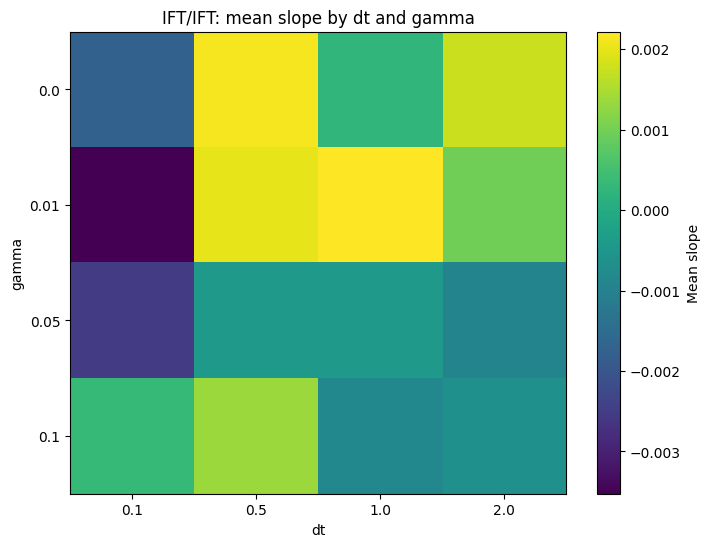

In [9]:
import matplotlib.pyplot as plt
ift_only_df = analysis_df[
    (analysis_df["aggregator"] == "ift") &
    (analysis_df["update"] == "ift_update")
].copy()

metric = "slope"

heat_df = (
    ift_only_df
    .groupby(["k0", "gamma"])
    .agg(mean_metric=(metric, "mean"))
    .reset_index()
)

pivot = heat_df.pivot(index="gamma", columns="k0", values="mean_metric")

plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label=f"Mean {metric}")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("dt")
plt.ylabel("gamma")
plt.title(f"IFT/IFT: mean {metric} by dt and gamma")
plt.show()

In [10]:
import numpy as np
import pandas as pd

rank_df = diagnostic_df.copy()

# ---------------------------------------------------
# Keep only rows with the needed metrics
# ---------------------------------------------------
needed = ["run_name", "global_pearson", "global_spearman", "std_ratio", "slope", "mae"]
rank_df = rank_df.dropna(subset=needed).copy()

# ---------------------------------------------------
# Goodness transforms
# ---------------------------------------------------
# correlations: higher is better
rank_df["pearson_good"] = rank_df["global_pearson"]
rank_df["spearman_good"] = rank_df["global_spearman"]

# slope: best when close to 1
rank_df["slope_good"] = 1.0 / (1.0 + np.abs(rank_df["slope"] - 1.0))

# std ratio: best when close to 1
rank_df["std_good"] = 1.0 / (1.0 + np.abs(rank_df["std_ratio"] - 1.0))

# MAE: lower is better, so min-max invert it
mae_min = rank_df["mae"].min()
mae_max = rank_df["mae"].max()

if mae_max - mae_min < 1e-12:
    rank_df["mae_good"] = 1.0
else:
    rank_df["mae_good"] = 1.0 - (rank_df["mae"] - mae_min) / (mae_max - mae_min)

# ---------------------------------------------------
# Weighted overall score
# You can tweak these weights
# ---------------------------------------------------
w_pearson = 0.25
w_spearman = 0.20
w_slope = 0.20
w_std = 0.20
w_mae = 0.15

rank_df["overall_score"] = (
    w_pearson * rank_df["pearson_good"] +
    w_spearman * rank_df["spearman_good"] +
    w_slope * rank_df["slope_good"] +
    w_std * rank_df["std_good"] +
    w_mae * rank_df["mae_good"]
)

# ---------------------------------------------------
# Show top 20 runs
# ---------------------------------------------------
top20_overall = rank_df.sort_values("overall_score", ascending=False).head(20).copy()

# pd.set_option("display.max_colwidth", None)
# display(
#     top20_overall[[
#         "run_name",
#         "overall_score",
#         "global_pearson",
#         "global_spearman",
#         "std_ratio",
#         "slope",
#         "mae",
#         "pearson_good",
#         "spearman_good",
#         "std_good",
#         "slope_good",
#         "mae_good",
#     ]]
# )

In [11]:
strict_df = diagnostic_df.copy()
strict_df = strict_df.dropna(subset=["run_name", "global_pearson", "global_spearman", "std_ratio", "slope", "mae"]).copy()

strict_df["pearson_good"] = strict_df["global_pearson"]
strict_df["spearman_good"] = strict_df["global_spearman"]
strict_df["slope_good"] = 1.0 / (1.0 + np.abs(strict_df["slope"] - 1.0))
strict_df["std_good"] = 1.0 / (1.0 + np.abs(strict_df["std_ratio"] - 1.0))

mae_min = strict_df["mae"].min()
mae_max = strict_df["mae"].max()
if mae_max - mae_min < 1e-12:
    strict_df["mae_good"] = 1.0
else:
    strict_df["mae_good"] = 1.0 - (strict_df["mae"] - mae_min) / (mae_max - mae_min)

strict_df["overall_score"] = (
    0.25 * strict_df["pearson_good"] +
    0.20 * strict_df["spearman_good"] +
    0.20 * strict_df["slope_good"] +
    0.20 * strict_df["std_good"] +
    0.15 * strict_df["mae_good"]
)

# penalty mask for obviously ugly runs
bad_mask = (
    (strict_df["slope"] <= 0) |
    (strict_df["std_ratio"] < 0.25) |
    (strict_df["std_ratio"] > 2.5)
)

strict_df.loc[bad_mask, "overall_score"] *= 0.5

top20_strict = strict_df.sort_values("overall_score", ascending=False).head(20).copy()

pd.set_option("display.max_colwidth", None)
# display(
#     top20_strict[[
#         "run_name",
#         "overall_score",
#         "global_pearson",
#         "global_spearman",
#         "std_ratio",
#         "slope",
#         "mae",
#     ]]
# )

In [12]:
def quality_label(row):
    if (
        row["global_pearson"] > 0.5 and
        row["global_spearman"] > 0.5 and
        0.7 <= row["slope"] <= 1.3 and
        0.7 <= row["std_ratio"] <= 1.3
    ):
        return "looks promising"
    elif (
        row["global_pearson"] > 0.4 and
        row["global_spearman"] > 0.4 and
        0.5 <= row["slope"] <= 1.6 and
        0.5 <= row["std_ratio"] <= 1.6
    ):
        return "mixed"
    else:
        return "sus"

strict_df["plot_quality_guess"] = strict_df.apply(quality_label, axis=1)

display(
    strict_df.sort_values("overall_score", ascending=False).head(30)[[
        "run_name", "overall_score", "plot_quality_guess",
        "global_pearson", "global_spearman", "std_ratio", "slope", "mae"
    ]]
)

,run_name,overall_score,plot_quality_guess,global_pearson,global_spearman,std_ratio,slope,mae
80,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-1.0__cap-none_seed-42,0.427222,sus,0.005136,0.015568,0.995279,0.005112,0.002308
104,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.01__k0-1.0__cap-none_seed-42,0.413655,sus,0.001335,-0.003512,0.912259,0.001218,0.002156
128,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.0__k0-1.0__cap-none_seed-42,0.411358,sus,0.004591,0.017460,1.103270,0.005065,0.002269
75,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.5__cap-none_seed-0,0.406477,sus,0.012627,0.027183,1.089058,0.013752,0.002536
63,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.05__k0-0.5__cap-none_seed-0,0.406077,sus,0.005663,-0.002319,0.906070,0.005131,0.002341
51,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.01__k0-0.5__cap-none_seed-0,0.404934,sus,0.002436,-0.000920,0.973825,0.002372,0.002629
127,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.0__k0-1.0__cap-none_seed-123,0.404822,sus,0.007284,-0.000004,0.809892,0.005899,0.002052
72,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.0__k0-0.1__cap-none_seed-0,0.400557,sus,0.002826,-0.011010,1.028267,0.002906,0.002677
90,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.1__k0-1.0__cap-none_seed-0,0.400494,sus,0.007916,0.020599,0.782301,0.006192,0.002162
49,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.05__gamma-0.01__k0-0.1__cap-none_seed-123,0.397284,sus,0.000334,-0.009369,0.973756,0.000325,0.002751
